# 3. k-nearest-neighbours regression

A non-parametric alternative to the linear models: each prediction is the mean
response of the `k` closest training points. If a non-linear relationship exists
that least squares is missing, this is where it should show up.

Standardising matters more here than anywhere else — distances are computed
directly on the features, so an unscaled predictor with a large range would
dominate every neighbour calculation.

In [1]:
import sys
sys.path.append("..")

import numpy as np

from src.data import load_airfoil_data, prepare_airfoil_xy, airfoil_feature_names
from src.preprocessing import standardise, apply_standardisation, add_intercept
from src.metrics import mse, rsquare
from src.plotting import metrics_table
from src.results import record_result

from src.knn import knn_predict
from src.model_selection import make_folds, choose_best_k, DEFAULT_SEED
from src.plotting import plot_curve

In [2]:
train_df, test_df = load_airfoil_data()
feature_names = airfoil_feature_names(train_df)

X_raw, y = prepare_airfoil_xy(train_df)
X_test_raw, y_test = prepare_airfoil_xy(test_df)

# Standardise on the training set, then reuse mu and sigma on the test set so
# both sit on the same scale.
X, mu, sigma = standardise(X_raw)
X_test = apply_standardisation(X_test_raw, mu, sigma)

# A column of ones lets the intercept be fitted as another weight.
X = add_intercept(X)
X_test = add_intercept(X_test)

print(f"train {X.shape}, test {X_test.shape}")
print("features:", feature_names)

train (3890, 7), test (973, 7)
features: ['Frequency', 'Angle', 'Displacement', 'Chord length', 'Velocity', 'Thickness']


## Choosing k by cross-validation

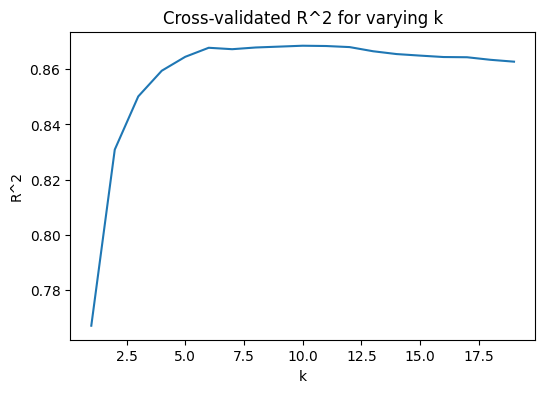

best k: 10


In [3]:
folds = make_folds(len(y), 5, rng=DEFAULT_SEED)

k_range = np.arange(1, 20)
best_k, k_scores = choose_best_k(X, y, folds, k_range)

plot_curve(k_range, k_scores, "k", "R^2",
           "Cross-validated R^2 for varying k")
print(f"best k: {best_k}")

## Performance at the selected k

In [4]:
knn_train_pred = knn_predict(X, y, X, k=best_k)
knn_test_pred = knn_predict(X, y, X_test, k=best_k)

knn_train = (mse(y, knn_train_pred), rsquare(y, knn_train_pred))
knn_test = (mse(y_test, knn_test_pred), rsquare(y_test, knn_test_pred))

print(f"training MSE {knn_train[0]:.4f}, R^2 {knn_train[1]:.4f}")
print(f"test MSE     {knn_test[0]:.4f}, R^2 {knn_test[1]:.4f}")

record_result("kNN", "train", mse=knn_train[0], r_squared=knn_train[1])
record_result("kNN", "test", mse=knn_test[0], r_squared=knn_test[1])

training MSE 2.3574, R^2 0.8966
test MSE     2.9857, R^2 0.8621


,model,split,mse,r_squared
0,Elastic net,test,1.984829,0.908297
1,Elastic net,train,1.875560,0.917734
2,Lasso,test,1.984805,0.908298
3,Lasso,train,1.875886,0.917720
4,Least squares,test,1.984390,0.908317
5,Least squares,train,1.875557,0.917734
6,kNN,test,2.985675,0.862056
7,kNN,train,2.357387,0.896600


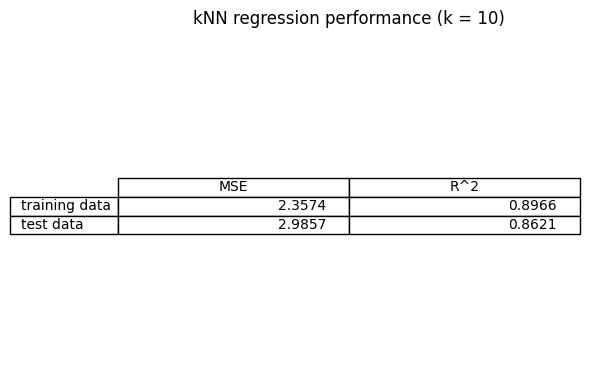

In [5]:
metrics_table([list(knn_train), list(knn_test)],
              columns=("MSE", "R^2"),
              row_labels=("training data", "test data"),
              title=f"kNN regression performance (k = {best_k})")

## Discussion

kNN records much the lowest R^2 of the four regression methods. On the test set:

| Model | Test MSE | Test R^2 |
|---|---|---|
| Least squares | 1.9844 | 0.9083 |
| Lasso | 1.9848 | 0.9083 |
| Elastic net | 1.9848 | 0.9083 |
| kNN | 2.9857 | 0.8621 |

The three linear models are indistinguishable to four decimal places — the
shrinkage buys essentially nothing on this data — while kNN trails them by about
five percentage points of R^2 and carries a materially higher MSE.

That gap suggests the relationship between the predictors and sound pressure is
strongly linear, and already well captured by the linear models. Had there been
substantial non-linear structure, kNN would have been expected to close the gap
or overtake them.

**Next:** [04_random_forest_classification.ipynb](04_random_forest_classification.ipynb)